# Guardrail Sandwich — LangChain Middleware

> "For destructive actions, put a slice of bread on both sides."

This notebook implements Guardrail Sandwich using the **LangChain v1 middleware API**:

- `@wrap_tool_call` decorator — one function, one guard
- `AgentMiddleware` subclass — multi-hook, composable sandwich
- `create_agent` — wire middleware into a real agent loop

Everything runs against `create_agent` with a live LLM. Default: AI Studio + `ernie-5.1` (OpenAI-compatible).
See [`.env.example`](../../../.env.example) for provider config, [`model_config.py`](../../../model_config.py) for the shared model loader.

## What this pattern does

Guardrail Sandwich wraps a risky tool call with two deterministic layers:

1. **Pre-hooks** decide whether the action is allowed to run.
2. **The tool step** performs the action.
3. **Post-hooks** verify the result after the action runs.

In the [graph version](../langgraph/tutorial.ipynb), these are three explicit nodes. In the middleware version, they are invisible interceptors inside `wrap_tool_call` — the tool author never sees them.

| | `langgraph/` (StateGraph) | `langchain/` (Middleware) |
|---|---|---|
| **Mechanism** | Explicit nodes + edges | Invisible interceptors on the tool-call pipeline |
| **Best for** | Learning, debugging, custom topology | Shipping fast, adding guardrails to existing agents |
| **Trade-off** | More code, more control | Less code, less visibility |

## Setup

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path
from typing import Any

# shared.py lives in the pattern folder (the parent dir); model_config.py and
# nbtools.py at the repo root. Find each by walking up, so the notebook isn't
# tied to a fixed folder depth (no brittle "../../.." counting).
for _marker in ("shared.py", "model_config.py", "nbtools.py"):
    _dir = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / _marker).exists())
    sys.path.insert(0, str(_dir))

# Official LangChain v1 middleware API
from langchain.agents import create_agent
from langchain.agents.middleware import AgentMiddleware, wrap_tool_call
from langchain_core.messages import ToolMessage
from langchain_core.tools import tool

# Shared model loader, hook factories/runner, and graph renderer — same modules as the langgraph/ notebook.
from model_config import get_model
from shared import (
    HookPhase, HookResult,
    amount_threshold_hook, blocklist_hook, output_schema_hook,
    applicable_hooks, run_single_hook,
)
from nbtools import show_graph

In [2]:
# Load the configured LLM — defaults to openai:ernie-5.1
model = get_model()

Model: ernie:ernie-5.1


## The tool

A simple banking transfer tool. The agent will call this when a user asks to move money.

In [3]:
@tool
def transfer(account: str, amount: float, memo: str) -> dict:
    """Transfer funds to an account. Returns a receipt."""
    return {"status": "ok", "account": account, "amount": amount, "tx_id": "TX-20250610-001"}

## Style A: `@wrap_tool_call` — the decorator guard

`wrap_tool_call` from `langchain.agents.middleware` turns a plain function into an `AgentMiddleware` instance. The function receives `(request, handler)`:

- Return a `ToolMessage` to **block** — the tool never runs
- Call `handler(request)` to **allow** — the tool executes normally

Under the hood, the decorator creates `type(fn.__name__, (AgentMiddleware,), {...})` — so the result can be passed directly to `create_agent(middleware=[...])`.

In [4]:
# A single decorator guard that blocks transfers over 1M.
# The closure captures the threshold so different agents can use different limits.
@wrap_tool_call
def amount_guard(request, handler):
    amount = request.tool_call["args"].get("amount", 0)
    if amount > 1_000_000:
        return ToolMessage(
            content=f"BLOCKED: amount {amount} exceeds threshold 1,000,000",
            tool_call_id=request.tool_call["id"],
        )
    return handler(request)

print(f"amount_guard type: {type(amount_guard).__name__}")
print(f"Is AgentMiddleware? {isinstance(amount_guard, AgentMiddleware)}")

amount_guard type: amount_guard
Is AgentMiddleware? True


### Test: decorator guard with `create_agent`

Pass the guard to `create_agent(middleware=[...])`. The agent calls the tool normally — the middleware intercepts transparently.

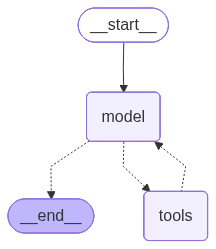

In [5]:
# create_agent returns a CompiledStateGraph — same type as langgraph/ graphs.
agent_a = create_agent(model=model, tools=[transfer], middleware=[amount_guard])

# Middleware is invisible, but the tool-call loop is visible in the graph.
show_graph(agent_a, alt="Agent with amount_guard middleware")

In [6]:
# Normal transfer — should pass through the guard
result = agent_a.invoke({"messages": [{"role": "user", "content": "Transfer 4200 to CORP-1234 for invoice 42"}]})
for msg in result["messages"]:
    print(f"  {type(msg).__name__}: {str(msg.content)[:120]}")

  HumanMessage: Transfer 4200 to CORP-1234 for invoice 42
  AIMessage: 
  ToolMessage: {"status": "ok", "account": "CORP-1234", "amount": 4200.0, "tx_id": "TX-20250610-001"}
  AIMessage: The transfer of $4,200 to account CORP-1234 for invoice 42 has been completed successfully.  
**Transaction ID**: TX-202


In [7]:
# Over-limit transfer — the guard should block before the tool runs
result = agent_a.invoke({"messages": [{"role": "user", "content": "Transfer 5000000 to CORP-1234 for Q2 bonus"}]})
for msg in result["messages"]:
    print(f"  {type(msg).__name__}: {str(msg.content)[:120]}")

  HumanMessage: Transfer 5000000 to CORP-1234 for Q2 bonus
  AIMessage: 
  ToolMessage: BLOCKED: amount 5000000 exceeds threshold 1,000,000
  AIMessage: The transfer of 5,000,000 was blocked because it exceeds the maximum allowed threshold of 1,000,000 per transaction. 

W


## Style B: `GuardrailSandwichMiddleware` — the composable class

For multiple hooks, we subclass the official `AgentMiddleware` and override `wrap_tool_call`. It takes one list of hook config dicts and, inside the tool-call interceptor:

1. **Pre-hooks** in priority order — first `BLOCK` stops the pipeline
2. **Tool execution** — only if all pre-hooks pass
3. **Post-hooks** for audit — all run even after a `BLOCK` (audit completeness)

The selection (`applicable_hooks`) and execution (`run_single_hook`) come from the shared [`shared.py`](../shared.py) — the *same* functions the langgraph/ nodes call — so the three critical behaviors are identical on both sides:
- **Fail-closed:** hook crash → `BLOCK`. A broken guardrail must not become an open door.
- **Shadow mode:** `blocks=False` downgrades `BLOCK` to `WARN` — the tool still runs.
- **`applies_to`:** hooks can target specific tools by name (and `phase` splits pre vs post).

In [8]:
def _decode(result: Any) -> Any:
    """Tool output reaches the middleware as a ToolMessage whose `.content` is
    a JSON string. Decode it to the plain dict the POST hooks expect — the same
    normalization the langgraph/ post_hooks_node does via decode_tool_message,
    so output_schema_hook validates the receipt, not its message wrapper."""
    content = getattr(result, "content", result)
    text = content if isinstance(content, str) else str(content)
    stripped = text.strip()
    if stripped.startswith("{") or stripped.startswith("["):
        try:
            return json.loads(stripped)
        except json.JSONDecodeError:
            return content
    return content


class GuardrailSandwichMiddleware(AgentMiddleware):
    """pre-hooks → tool → post-hooks, with fail-closed and shadow mode.

    Extends the official AgentMiddleware base class. Takes ONE list of hook
    config dicts (same shape and same `shared.py` factories as the langgraph/
    notebook); `applicable_hooks` splits them by phase + `applies_to`, and
    `run_single_hook` applies the fail-closed / shadow-mode rules — so both
    notebooks share the exact selection and execution logic.

    Post-hooks detect, they don't roll back (rollback is a separate pattern):
    the tool result still flows, but the audit record is kept on `last_trace`
    — the middleware analogue of the langgraph/ print_trace output.
    """

    def __init__(self, hooks=None):
        super().__init__()
        self.hooks = hooks or []
        self.last_trace: dict[str, Any] = {}

    def wrap_tool_call(self, request, handler):
        """The sandwich: pre-hooks → tool → post-hooks."""
        tool_name = request.tool_call.get("name", "")
        args = request.tool_call.get("args", {})
        tool_call_id = request.tool_call.get("id", "")
        trace = {"pre_outcomes": [], "post_outcomes": [], "blocked": False, "rollback_marked": False}
        self.last_trace = trace

        # 1. Pre-hooks — first BLOCK stops the pipeline, tool never runs.
        for hook_cfg in applicable_hooks(self.hooks, HookPhase.PRE, tool_name):
            outcome = run_single_hook(hook_cfg, tool_name, args, None)
            trace["pre_outcomes"].append(outcome)
            if outcome["result"] == HookResult.BLOCK.value and hook_cfg.get("blocks", True):
                trace["blocked"] = True
                return ToolMessage(
                    content=f"BLOCKED by {outcome['hook_name']}: {outcome['reason']}",
                    tool_call_id=tool_call_id,
                )

        # 2. Tool execution.
        result = handler(request)
        output = _decode(result)  # ToolMessage -> dict, so post-hooks see the receipt

        # 3. Post-hooks — all run for audit completeness, even after a BLOCK.
        for hook_cfg in applicable_hooks(self.hooks, HookPhase.POST, tool_name):
            outcome = run_single_hook(hook_cfg, tool_name, args, output)
            trace["post_outcomes"].append(outcome)
            if outcome["result"] == HookResult.BLOCK.value and hook_cfg.get("blocks", True):
                trace["rollback_marked"] = True

        return result

### Hook factories

The hook factories (`amount_threshold_hook`, `blocklist_hook`, `output_schema_hook`) are imported from the shared [`shared.py`](../shared.py) — same definitions used by the langgraph/ notebook. Each returns a config dict carrying `phase` (PRE/POST), `priority`, `blocks`, and `applies_to`.

In [9]:
# Quick check: the imported factories return config dicts with fn inlined.
sample = amount_threshold_hook("amount", 1_000_000)
print(f"Hook config keys: {sorted(sample.keys())}")
print(f"Hook name: {sample['name']}, phase: {sample['phase']}")

Hook config keys: ['applies_to', 'blocks', 'fn', 'name', 'phase', 'priority']
Hook name: amount_threshold, phase: pre


### Test: class middleware with `create_agent`

Wire the `GuardrailSandwichMiddleware` into a real agent. The agent calls tools normally — the middleware intercepts every tool call transparently.

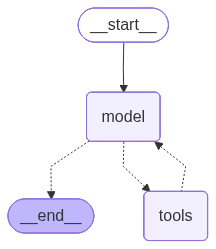

In [10]:
# Build the sandwich from one hook list — phase splits them into pre/post.
sandwich = GuardrailSandwichMiddleware(
    hooks=[
        amount_threshold_hook("amount", 1_000_000),   # PRE
        blocklist_hook("account", {"BLOCKED-999", "SANCTIONED-001"}),  # PRE
        output_schema_hook(["status", "tx_id"]),       # POST
    ],
)

agent_b = create_agent(model=model, tools=[transfer], middleware=[sandwich])

# Same CompiledStateGraph — middleware hooks are wired inside the tool_call node.
show_graph(agent_b, alt="Agent with GuardrailSandwichMiddleware")

In [11]:
# Normal transfer — pre-hooks pass, tool runs, post-hooks pass
result = agent_b.invoke({"messages": [{"role": "user", "content": "Transfer 4200 to CORP-1234 for invoice 42"}]})
for msg in result["messages"]:
    print(f"  {type(msg).__name__}: {str(msg.content)[:120]}")

  HumanMessage: Transfer 4200 to CORP-1234 for invoice 42
  AIMessage: 
  ToolMessage: {"status": "ok", "account": "CORP-1234", "amount": 4200.0, "tx_id": "TX-20250610-001"}
  AIMessage: The transfer of $4,200 to account CORP-1234 for invoice 42 has been completed successfully.  
**Transaction ID**: TX-202


In [12]:
# The middleware keeps the full audit on `last_trace`. After a successful
# transfer it shows the post-hooks running on the DECODED receipt (a dict, not
# the ToolMessage) — output_schema passes. This is the langchain analogue of
# the langgraph/ print_trace output.
from pprint import pprint

pprint(sandwich.last_trace)

{'blocked': False,
 'post_outcomes': [{'hook_name': 'output_schema',
                    'phase': 'post',
                    'reason': 'output schema valid',
                    'result': 'pass'}],
 'pre_outcomes': [{'hook_name': 'amount_threshold',
                   'phase': 'pre',
                   'reason': 'amount=4200 within limit',
                   'result': 'pass'},
                  {'hook_name': 'blocklist',
                   'phase': 'pre',
                   'reason': 'account clear',
                   'result': 'pass'}],
 'rollback_marked': False}


In [13]:
# Sanctioned account — blocklist pre-hook should block
result = agent_b.invoke({"messages": [{"role": "user", "content": "Transfer 500 to SANCTIONED-001 for advisory fee"}]})
for msg in result["messages"]:
    print(f"  {type(msg).__name__}: {str(msg.content)[:120]}")

  HumanMessage: Transfer 500 to SANCTIONED-001 for advisory fee
  AIMessage: 
  ToolMessage: BLOCKED by blocklist: account='SANCTIONED-001' on blocklist
  AIMessage: The transfer to **SANCTIONED-001** was blocked because the account is on a blocklist. This transaction cannot be process


## Stacking both styles

You can mix decorator guards and class middleware in the same `create_agent` call. The middleware stack processes in order — decorator first, then class:

```python
agent = create_agent(
    model=model,
    tools=[transfer],
    middleware=[
        amount_guard,       # @wrap_tool_call (Style A) — simple threshold
        sandwich,           # GuardrailSandwichMiddleware (Style B) — blocklist + schema
    ],
)
```

## Production shortcuts

LangChain v1 ships prebuilt middleware for common guardrail patterns:

```python
from langchain.agents.middleware import PIIMiddleware, HumanInTheLoopMiddleware

agent = create_agent(
    model=model,
    tools=[transfer],
    middleware=[
        PIIMiddleware("credit_card", strategy="redact"),
        HumanInTheLoopMiddleware(interrupt_on={"transfer": True}),
        sandwich,  # your custom hooks compose alongside prebuilts
    ],
)
```

Use prebuilts for commodity guardrails; build custom for domain-specific logic.

## What to remember

- `@wrap_tool_call` turns one function into a full `AgentMiddleware` — simplest form for a single guard.
- `GuardrailSandwichMiddleware` subclasses `AgentMiddleware` for multi-hook, composable sandwiches.
- Both styles plug into `create_agent(middleware=[...])` — no graph topology needed.
- Hook crash = `BLOCK`, not `PASS`. Shadow mode (`blocks=False`) lets you canary-test new hooks.
- Pre-hooks short-circuit; post-hooks all run for audit completeness.

## Further reading

- [Graph version](../langgraph/tutorial.ipynb) — the same Guardrail Sandwich pattern implemented as a visible LangGraph `StateGraph` with explicit `pre_hooks → execute_tool → post_hooks` nodes
- [Parent pattern README](../../README.md) — full design rationale, failure mode taxonomy, hook contract specification, and engineering references for the pure-Python implementation
- [REFERENCE_IMPL.md](../../../REFERENCE_IMPL.md) — how to install `uv`, sync dependencies, launch JupyterLab, and run all tutorial notebooks
- [LangChain Guardrails guide](https://docs.langchain.com/oss/python/langchain/guardrails) — official LangChain documentation on input/output guardrails, content filtering, and safety middleware
- [Custom middleware guide](https://docs.langchain.com/oss/python/langchain/middleware/custom) — how to write your own `AgentMiddleware` subclass with `wrap_tool_call`, `wrap_model_call`, and `before_agent` hooks
- [Middleware overview](https://docs.langchain.com/oss/python/langchain/middleware) — complete list of built-in middleware (`PIIMiddleware`, `HumanInTheLoopMiddleware`, `TodoListMiddleware`, `ToolCallLimitMiddleware`, etc.) and how they compose
- [OWASP Top 10 for Agentic Applications](https://genai.owasp.org/) — security risks specific to LLM agents, including tool misuse, excessive autonomy, and prompt injection — the threats guardrails are designed to mitigate